# 🎮 Video Game Sales Analysis
### Data Analysis using Pandas, NumPy, Matplotlib & Seaborn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

## 1. Load Dataset

In [2]:
df = pd.read_csv(r'C:\Python Practice\vgsales.csv')
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Rating,Global_Sales
0,1,Grand Theft Auto V,Wii,2018.0,Adventure,EA,1.47,0.76,0.45,0.22,M,2.90
1,2,Call of Duty: Black Ops,Switch,2015.0,Simulation,Bandai Namco,1.05,0.07,0.25,0.16,E10+,1.53
2,3,Minecraft,DS,2013.0,Sports,Nintendo,2.91,0.15,0.29,1.21,T,4.56
3,4,Red Dead Redemption 2,PS3,2015.0,Adventure,Konami,1.61,0.15,1.17,0.04,T,2.97
4,5,FIFA 22,Wii,2017.0,Action,Nintendo,0.27,1.26,0.21,0.15,AO,1.89


## 2. Dataset Overview

In [3]:
print("== DATASET INFORMATION ==")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nData Types:")
print(df.dtypes)
print(f"\nMissing Values:\n{df.isnull().sum()}")

== DATASET INFORMATION ==
Shape: (108, 12)
Columns: ['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Rating', 'Global_Sales']

Data Types:
Rank              int64
Name                str
Platform            str
Year            float64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Rating              str
Global_Sales    float64
dtype: object

Missing Values:
Rank             0
Name             0
Platform         0
Year            10
Genre            0
Publisher        6
NA_Sales         0
EU_Sales         0
JP_Sales         0
Other_Sales      0
Rating          22
Global_Sales     0
dtype: int64


In [4]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,108.00000,98.000000,108.000000,108.00000,108.000000,108.000000,108.000000
mean,54.50000,2017.081633,1.595926,1.54787,0.381944,0.298796,3.824537
std,31.32092,2.823588,1.517539,1.63628,0.405319,0.272379,2.329363
min,1.00000,2013.000000,0.020000,0.01000,0.010000,0.010000,0.400000
25%,27.75000,2015.000000,0.457500,0.40000,0.100000,0.090000,1.942500
50%,54.50000,2017.000000,1.190000,1.05000,0.235000,0.220000,3.270000
75%,81.25000,2019.000000,2.342500,2.19750,0.490000,0.432500,5.445000
max,108.00000,2022.000000,6.990000,9.81000,2.150000,1.380000,11.640000


## 3. Data Cleaning

In [5]:
print("Before cleaning:")
print(df.isnull().sum())

# Fill missing values
df['Publisher'] = df['Publisher'].fillna('Unknown')
df['Rating']    = df['Rating'].fillna('Not Rated')
df['Year']      = df['Year'].fillna(df['Year'].median())
df['Year']      = df['Year'].astype(int)

print("\nAfter cleaning:")
print(df.isnull().sum())

Before cleaning:
Rank             0
Name             0
Platform         0
Year            10
Genre            0
Publisher        6
NA_Sales         0
EU_Sales         0
JP_Sales         0
Other_Sales      0
Rating          22
Global_Sales     0
dtype: int64

After cleaning:
Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Rating          0
Global_Sales    0
dtype: int64


## 4. NumPy Operations

In [6]:
# NumPy statistical operations on sales data
sales = df['Global_Sales'].values  # Convert to NumPy array

print("== NumPy Sales Statistics ==")
print(f"Total Global Sales  : {np.sum(sales):.2f} million")
print(f"Mean Sales          : {np.mean(sales):.2f} million")
print(f"Median Sales        : {np.median(sales):.2f} million")
print(f"Std Deviation       : {np.std(sales):.2f} million")
print(f"Min Sales           : {np.min(sales):.2f} million")
print(f"Max Sales           : {np.max(sales):.2f} million")
print(f"25th Percentile     : {np.percentile(sales, 25):.2f} million")
print(f"75th Percentile     : {np.percentile(sales, 75):.2f} million")

# NumPy array operations
na_sales  = df['NA_Sales'].values
eu_sales  = df['EU_Sales'].values
jp_sales  = df['JP_Sales'].values

# Recalculate global sales using NumPy
recalc_global = np.add(np.add(na_sales, eu_sales), jp_sales) 
print(f"\nNumPy recalculated total: {np.sum(recalc_global):.2f} million")

# Log transformation (useful for skewed sales data)
log_sales = np.log1p(sales)
print(f"\nLog-transformed sales - Mean: {np.mean(log_sales):.3f}, Std: {np.std(log_sales):.3f}")

== NumPy Sales Statistics ==
Total Global Sales  : 413.05 million
Mean Sales          : 3.82 million
Median Sales        : 3.27 million
Std Deviation       : 2.32 million
Min Sales           : 0.40 million
Max Sales           : 11.64 million
25th Percentile     : 1.94 million
75th Percentile     : 5.45 million

NumPy recalculated total: 380.78 million

Log-transformed sales - Mean: 1.462, Std: 0.476


## 5. Feature Engineering

In [7]:
# 1. Sales Category based on Global Sales
def categorize_sales(sales):
    if sales >= 5.0:
        return 'Blockbuster'
    elif sales >= 2.0:
        return 'Hit'
    elif sales >= 1.0:
        return 'Moderate'
    else:
        return 'Low'

df['Sales_Category'] = df['Global_Sales'].apply(categorize_sales)

# 2. Era based on Year
def get_era(year):
    if year <= 2006:
        return '6th Gen (2000-2006)'
    elif year <= 2012:
        return '7th Gen (2007-2012)'
    elif year <= 2016:
        return '8th Gen (2013-2016)'
    else:
        return '9th Gen (2017+)'

df['Era'] = df['Year'].apply(get_era)

# 3. NA Dominance flag - True if NA sales > 50% of global
df['NA_Dominant'] = df['NA_Sales'] > (df['Global_Sales'] * 0.5)

# 4. Sales Ratio columns using NumPy
df['NA_Ratio']    = np.round(df['NA_Sales']    / df['Global_Sales'] * 100, 2)
df['EU_Ratio']    = np.round(df['EU_Sales']    / df['Global_Sales'] * 100, 2)
df['JP_Ratio']    = np.round(df['JP_Sales']    / df['Global_Sales'] * 100, 2)

# 5. Popularity Score using NumPy
df['Popularity_Score'] = np.round(
    (df['Global_Sales'] / df['Global_Sales'].max()) * 10, 2
)

print("New features created:")
print(df[['Name', 'Sales_Category', 'Era', 'NA_Dominant', 'NA_Ratio', 'Popularity_Score']].head(8))

New features created:
                      Name Sales_Category                  Era  NA_Dominant  \
0       Grand Theft Auto V            Hit      9th Gen (2017+)         True   
1  Call of Duty: Black Ops       Moderate  8th Gen (2013-2016)         True   
2                Minecraft            Hit  8th Gen (2013-2016)         True   
3    Red Dead Redemption 2            Hit  8th Gen (2013-2016)         True   
4                  FIFA 22       Moderate      9th Gen (2017+)        False   
5            The Witcher 3            Hit      9th Gen (2017+)        False   
6               God of War            Hit  8th Gen (2013-2016)        False   
7               Spider-Man            Hit      9th Gen (2017+)        False   

   NA_Ratio  Popularity_Score  
0     50.69              2.49  
1     68.63              1.31  
2     63.82              3.92  
3     54.21              2.55  
4     14.29              1.62  
5      3.48              2.71  
6     38.89              3.40  
7      0.8

## 6. Filtering Operations

In [8]:
# 1. Blockbuster games
blockbusters = df[df['Sales_Category'] == 'Blockbuster']
print(f"Blockbuster games: {len(blockbusters)}")

# 2. Recent games (2018 onwards)
recent_games = df[df['Year'] >= 2018]
print(f"Recent games (2018+): {len(recent_games)}")

# 3. Action or Shooter games with high NA Sales
action_shooter = df[
    (df['Genre'].isin(['Action', 'Shooter'])) &
    (df['NA_Sales'] > 1.5)
]
print(f"Action/Shooter games with NA Sales > 1.5M: {len(action_shooter)}")

# 4. Games where Japan outsells North America
jp_dominant = df[df['JP_Sales'] > df['NA_Sales']]
print(f"Games where JP sales > NA sales: {len(jp_dominant)}")

# 5. Filter by Publisher using regex
nintendo_games = df[df['Publisher'].str.contains('Nintendo', na=False)]
print(f"Nintendo games: {len(nintendo_games)}")

Blockbuster games: 29
Recent games (2018+): 45
Action/Shooter games with NA Sales > 1.5M: 15
Games where JP sales > NA sales: 20
Nintendo games: 10


## 7. GroupBy Operations

In [9]:
# 1. Group by Genre
genre_stats = df.groupby('Genre').agg(
    Total_Games   = ('Name', 'count'),
    Avg_Global    = ('Global_Sales', 'mean'),
    Total_Sales   = ('Global_Sales', 'sum'),
    Max_Sales     = ('Global_Sales', 'max')
).round(2).sort_values('Total_Sales', ascending=False)

print("Genre-wise Statistics:")
print(genre_stats)

Genre-wise Statistics:
            Total_Games  Avg_Global  Total_Sales  Max_Sales
Genre                                                      
Shooter              16        4.04        64.72      11.64
Action               16        4.00        64.01       7.80
Adventure            13        3.53        45.86       5.97
Fighting             11        4.00        43.97       7.22
Puzzle               10        3.98        39.77       8.07
RPG                  10        3.68        36.83       6.03
Sports               10        3.54        35.38       5.41
Racing                9        3.87        34.82      11.31
Strategy              5        4.81        24.07       9.42
Simulation            8        2.95        23.62       8.73


In [10]:
# 2. Group by Platform
platform_stats = df.groupby('Platform').agg(
    Total_Games   = ('Name', 'count'),
    Total_Sales   = ('Global_Sales', 'sum'),
    NA_Sales      = ('NA_Sales', 'sum'),
    EU_Sales      = ('EU_Sales', 'sum'),
    JP_Sales      = ('JP_Sales', 'sum')
).round(2).sort_values('Total_Sales', ascending=False)

print("Platform-wise Statistics:")
print(platform_stats)

Platform-wise Statistics:
          Total_Games  Total_Sales  NA_Sales  EU_Sales  JP_Sales
Platform                                                        
DS                 17        66.85     29.04     24.91      7.04
Xbox One           11        50.08     25.05     16.46      5.43
PSP                11        49.81     16.62     24.30      3.63
Wii                13        42.39     16.25     19.37      3.85
PS3                11        39.52     23.76      9.09      3.68
3DS                12        38.43     18.96     11.59      4.39
Switch              9        36.67     14.98     14.02      5.05
PC                 10        33.13     13.85     11.35      5.02
PS4                 8        30.94      7.64     19.41      1.87
Xbox 360            6        25.23      6.21     16.67      1.29


In [11]:
# 3. Group by Publisher - Top 5
publisher_stats = df.groupby('Publisher').agg(
    Games_Published = ('Name', 'count'),
    Total_Sales     = ('Global_Sales', 'sum'),
    Avg_Sales       = ('Global_Sales', 'mean')
).round(2).sort_values('Total_Sales', ascending=False).head(5)

print("Top 5 Publishers by Sales:")
print(publisher_stats)

Top 5 Publishers by Sales:
              Games_Published  Total_Sales  Avg_Sales
Publisher                                            
Bandai Namco               18        67.01       3.72
Capcom                     12        47.32       3.94
Nintendo                   10        44.33       4.43
Ubisoft                     9        43.25       4.81
Sony                       13        40.83       3.14


In [12]:
# 4. Yearly sales trend
yearly_sales = df.groupby('Year').agg(
    Total_Games   = ('Name', 'count'),
    Total_Sales   = ('Global_Sales', 'sum'),
    Avg_Sales     = ('Global_Sales', 'mean')
).round(2)

print("Yearly Sales Trend:")
print(yearly_sales)

Yearly Sales Trend:
      Total_Games  Total_Sales  Avg_Sales
Year                                     
2013           15        55.57       3.70
2014            6        19.24       3.21
2015           12        51.42       4.28
2016           12        51.17       4.26
2017           18        72.00       4.00
2018           11        38.03       3.46
2019           13        50.24       3.86
2020            6        16.24       2.71
2021            8        37.62       4.70
2022            7        21.52       3.07


## 8. Melt / Reshape

In [13]:
# Reshape regional sales for comparison
region_df = df[['Name', 'Genre', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].head(20).copy()

melted_df = pd.melt(
    region_df,
    id_vars    = ['Name', 'Genre'],
    value_vars = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'],
    var_name   = 'Region',
    value_name = 'Sales_Million'
)

print(f"Original shape  : {region_df.shape}")
print(f"Melted shape    : {melted_df.shape}")
print("\nMelted sample:")
melted_df.head(10)

Original shape  : (20, 6)
Melted shape    : (80, 4)

Melted sample:


,Name,Genre,Region,Sales_Million
0,Grand Theft Auto V,Adventure,NA_Sales,1.47
1,Call of Duty: Black Ops,Simulation,NA_Sales,1.05
2,Minecraft,Sports,NA_Sales,2.91
3,Red Dead Redemption 2,Adventure,NA_Sales,1.61
4,FIFA 22,Action,NA_Sales,0.27
5,The Witcher 3,Puzzle,NA_Sales,0.11
6,God of War,Puzzle,NA_Sales,1.54
7,Spider-Man,Sports,NA_Sales,0.04
8,Fortnite,Simulation,NA_Sales,1.32
9,Cyberpunk 2077,Strategy,NA_Sales,4.23


## 9. Data Visualization

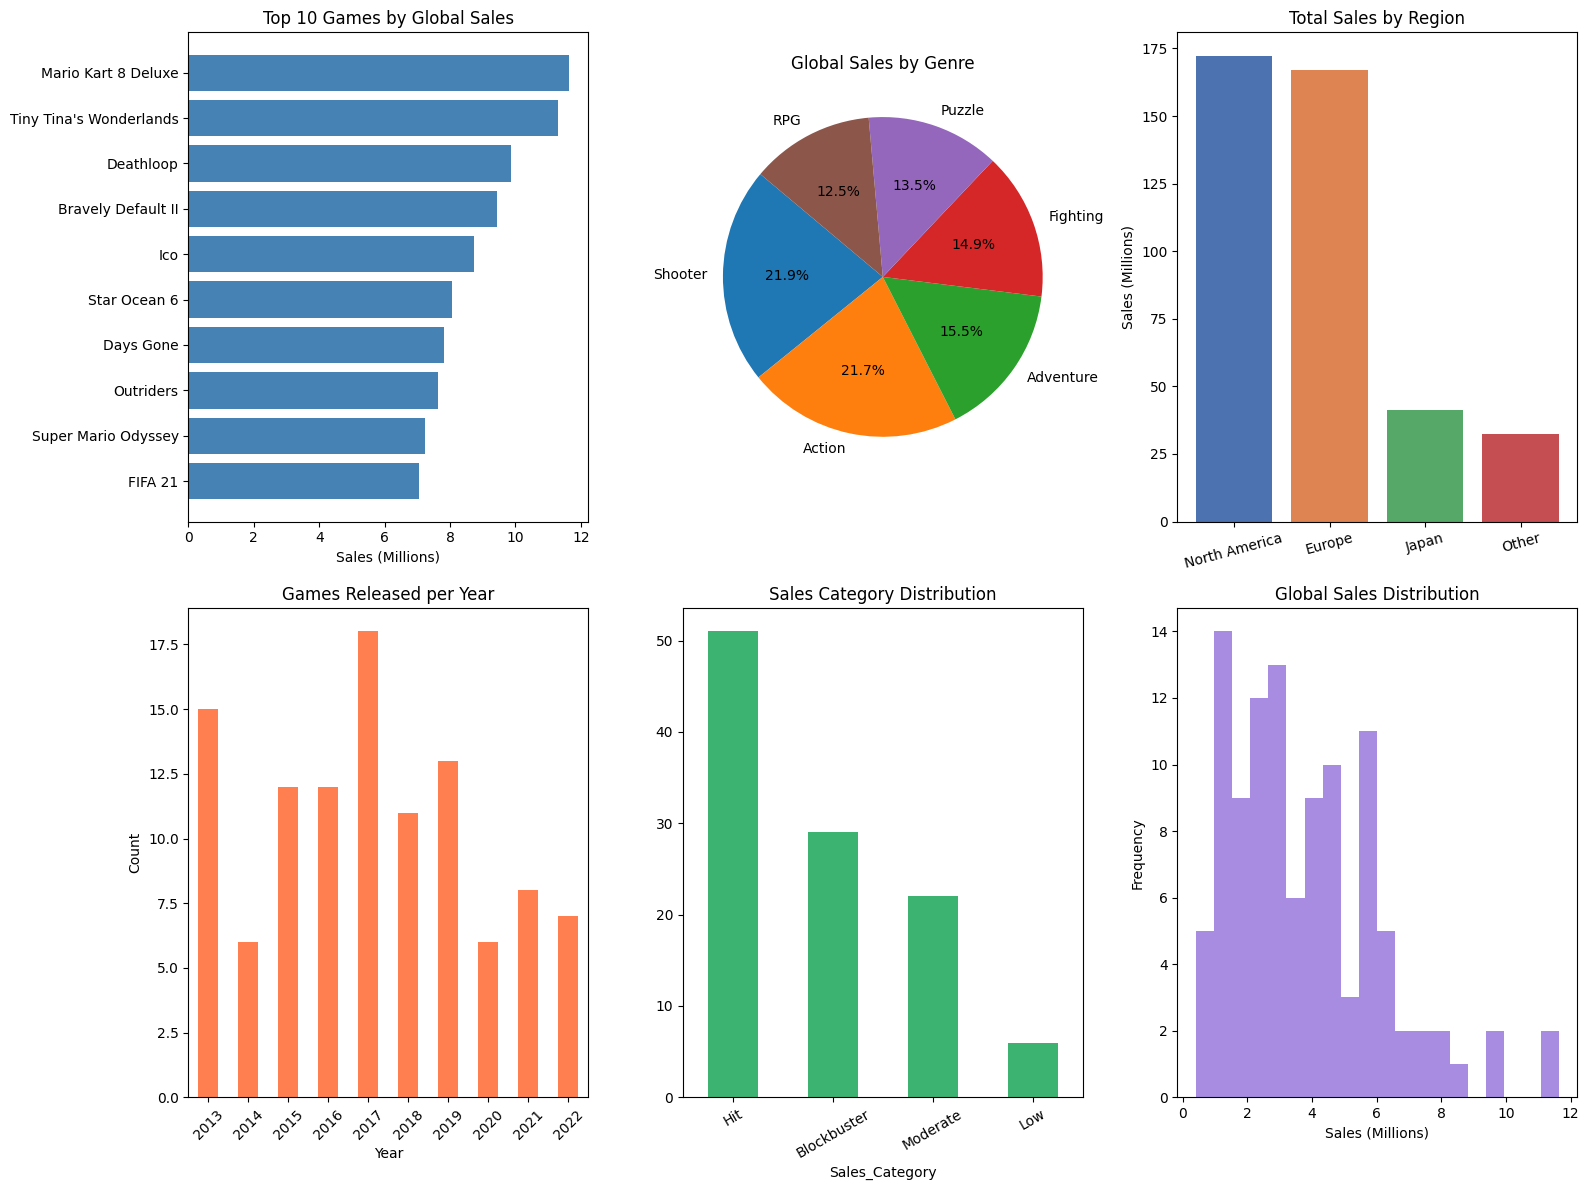

In [14]:
plt.figure(figsize=(16, 12))

# 1. Top 10 Games by Global Sales
plt.subplot(2, 3, 1)
top10 = df.nlargest(10, 'Global_Sales')
plt.barh(top10['Name'], top10['Global_Sales'], color='steelblue')
plt.title('Top 10 Games by Global Sales')
plt.xlabel('Sales (Millions)')
plt.gca().invert_yaxis()

# 2. Sales by Genre (pie)
plt.subplot(2, 3, 2)
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False).head(6)
plt.pie(genre_sales, labels=genre_sales.index, autopct='%1.1f%%', startangle=140)
plt.title('Global Sales by Genre')

# 3. Regional Sales Comparison
plt.subplot(2, 3, 3)
region_totals = {
    'North America' : df['NA_Sales'].sum(),
    'Europe'        : df['EU_Sales'].sum(),
    'Japan'         : df['JP_Sales'].sum(),
    'Other'         : df['Other_Sales'].sum()
}
plt.bar(region_totals.keys(), region_totals.values(), color=['#4C72B0','#DD8452','#55A868','#C44E52'])
plt.title('Total Sales by Region')
plt.ylabel('Sales (Millions)')
plt.xticks(rotation=15)

# 4. Games Released per Year
plt.subplot(2, 3, 4)
df['Year'].value_counts().sort_index().plot(kind='bar', color='coral')
plt.title('Games Released per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)

# 5. Sales Category Distribution
plt.subplot(2, 3, 5)
df['Sales_Category'].value_counts().plot(kind='bar', color='mediumseagreen')
plt.title('Sales Category Distribution')
plt.xticks(rotation=30)

# 6. Global Sales Distribution (Histogram)
plt.subplot(2, 3, 6)
plt.hist(df['Global_Sales'], bins=20, color='mediumpurple', alpha=0.8)
plt.title('Global Sales Distribution')
plt.xlabel('Sales (Millions)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

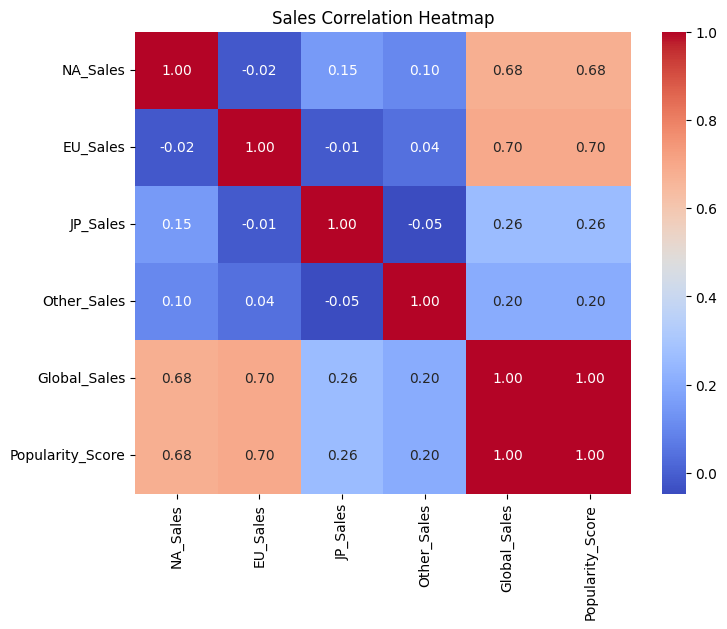

In [15]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
corr = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Popularity_Score']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Sales Correlation Heatmap')
plt.show()

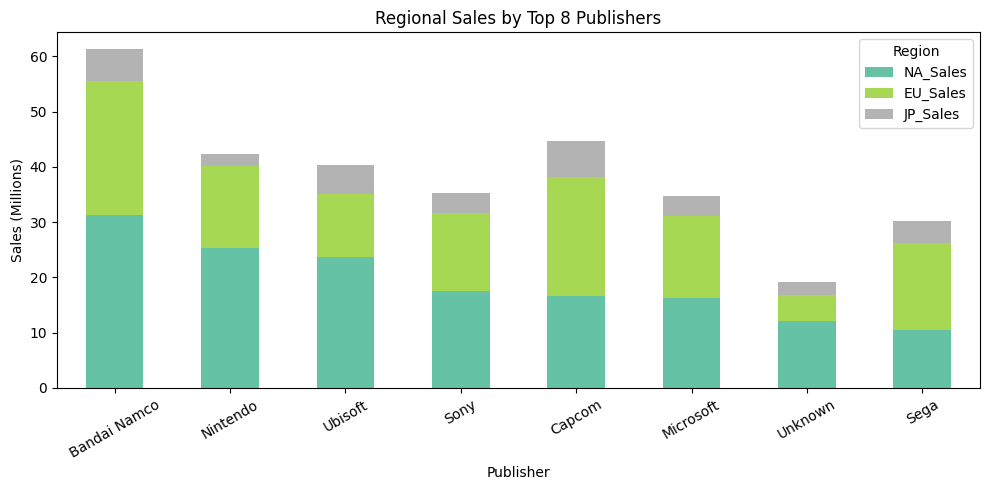

In [16]:
# Top Publishers - Stacked Bar
top_pubs = df.groupby('Publisher')[['NA_Sales','EU_Sales','JP_Sales']].sum().nlargest(8, columns=['NA_Sales'])
top_pubs.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='Set2')
plt.title('Regional Sales by Top 8 Publishers')
plt.xlabel('Publisher')
plt.ylabel('Sales (Millions)')
plt.xticks(rotation=30)
plt.legend(title='Region')
plt.tight_layout()
plt.show()

## 10. Final Summary

In [17]:
print("====== VIDEO GAME SALES ANALYSIS - SUMMARY ======")
print(f"Total Games Analyzed       : {len(df)}")
print(f"Total Global Sales         : {df['Global_Sales'].sum():.2f} Million")
print(f"Best Selling Game          : {df.loc[df['Global_Sales'].idxmax(), 'Name']}")
print(f"Most Popular Genre         : {df.groupby('Genre')['Global_Sales'].sum().idxmax()}")
print(f"Top Platform               : {df.groupby('Platform')['Global_Sales'].sum().idxmax()}")
print(f"Top Publisher              : {df.groupby('Publisher')['Global_Sales'].sum().idxmax()}")
print(f"Year with Most Releases    : {df['Year'].value_counts().idxmax()}")
print(f"Average Global Sales       : {np.mean(df['Global_Sales'].values):.2f} Million")
print(f"Blockbuster Games (>=5M)   : {len(df[df['Sales_Category']=='Blockbuster'])}")


====== VIDEO GAME SALES ANALYSIS - SUMMARY ======
Total Games Analyzed       : 108
Total Global Sales         : 413.05 Million
Best Selling Game          : Mario Kart 8 Deluxe
Most Popular Genre         : Shooter
Top Platform               : DS
Top Publisher              : Bandai Namco
Year with Most Releases    : 2017
Average Global Sales       : 3.82 Million
Blockbuster Games (>=5M)   : 29
